# MCDI505 — Análisis de Series de Tiempo
## Formativa 2 — Informe técnico de modelos clásicos (ARIMA / SARIMA) aplicado al consumo eléctrico comercial

| | |
|---|---|
| **Estudiante** | Claudio Rodolfo Alarcón Pradenas — Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello |
| **Docente** | Dr. Harvey Jezlid Rosas Quintero |
| **Evaluación** | Formativa 2 · Semana 2 · Fase 2 (búsqueda y recopilación activa de información) · 8 de octubre de 2026 |
| **Datos** | `consumo_electrico_litoral.csv` (caso transversal del curso) |
| **Repositorio (respaldo y reproducibilidad)** | `https://github.com/claudioalarconP/Analisis_de_serie_de_tiempo` |

## 1. Introducción y contexto del conjunto de datos

La Distribuidora Eléctrica del Litoral (DEL) compromete cada diciembre la energía mensual del año siguiente para su segmento comercial. Un error de contratación obliga a comprar en el mercado *spot* o a pagar energía no consumida (Universidad Andrés Bello [UNAB], s. f.-a). La variable de interés es `consumo_gwh` (GWh mensuales), y el horizonte de decisión es de **12 meses**.

| Periodo | Uso |
|---|---|
| 2015-01 a 2023-12 | Estacionariedad e identificación |
| 2015-01 a 2022-12 | Estimación |
| 2023-01 a 2023-12 | Validación (mismo periodo para todos los modelos) |
| 2024 | Sellado (Semana 4) |

**Objetivo.** Aplicar el ciclo de Box-Jenkins (Box et al., 2015) para identificar, estimar y seleccionar un modelo clásico adecuado para la serie, verificando que sus residuos presenten un comportamiento compatible con ruido blanco. El código adapta el notebook docente de la Sesión 2 (UNAB, s. f.-b) y usa `statsmodels` (Seabold y Perktold, 2010).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, statsmodels, statsmodels.api as sm
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, het_goldfeldquandt
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from IPython.display import display

warnings.filterwarnings("ignore")         # los avisos de CONVERGENCIA se capturan explícitamente (sección 3.2)
SEMILLA = 505; np.random.seed(SEMILLA)    # semilla del curso (la estimación MV es determinista)
S = 12                                    # periodo estacional mensual
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
                     "axes.titlesize": 11, "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
                     "legend.fontsize": 9, "axes.spines.top": False, "axes.spines.right": False})
ROJO, AZUL, GRIS = "#b30338", "#0057b8", "#9e9e9e"      # paleta de la Sumativa 1
VERDE, NARANJA, MORADO = "#2e7d32", "#ef6c00", "#6a1b9a"
pd.set_option("display.width", 140); pd.set_option("display.max_colwidth", 120)
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | statsmodels {statsmodels.__version__}")

Python 3.13.16 | pandas 3.0.5 | statsmodels 0.15.0


In [2]:
# --- Localización del CSV: VS Code, JupyterLab, Jupyter Notebook y Google Colab ---
ARCHIVO = "consumo_electrico_litoral.csv"
rutas_posibles = [
    Path(ARCHIVO),                          # junto al notebook (directorio de ejecución)
    Path("data/raw") / ARCHIVO,             # desde la raíz del proyecto
    Path("../data/raw") / ARCHIVO,          # un nivel superior
    Path("../../data/raw") / ARCHIVO,       # dos niveles superiores
    Path("../../../data/raw") / ARCHIVO,    # desde notebooks/semana_2/F2/
]
ruta = next((r for r in rutas_posibles if r.exists()), None)
if ruta is None:
    if "google.colab" in sys.modules:       # Google Colab: carga manual del CSV
        from google.colab import files
        files.upload()
        ruta = Path(ARCHIVO)
    else:
        raise FileNotFoundError(f"No se encontró {ARCHIVO}. Ubíquelo junto al notebook o dentro de data/raw.")
print(f"Dataset encontrado en: {ruta}")
df = pd.read_csv(ruta, parse_dates=["fecha"]).set_index("fecha").asfreq("MS")   # índice mensual

idx = df.index                                                                 # auditoría temporal
print(f"Filas: {len(df)} | {idx.min():%Y-%m} a {idx.max():%Y-%m} | frecuencia: {idx.freqstr} | "
      f"ordenado: {idx.is_monotonic_increasing} | duplicados: {idx.duplicated().sum()} | "
      f"meses ausentes: {len(pd.date_range(idx.min(), idx.max(), freq='MS').difference(idx))}")

periodo = df.loc[:"2023-12-01"].copy()            # 2024 SELLADO: df no vuelve a usarse
assert len(periodo) == 108 and not periodo.index.year.isin([2024]).any(), "2024 debe permanecer sellado"
s = periodo["consumo_gwh"]
huecos = s[s.isna()].index                                    # 2016-08, 2019-02, 2022-06
y = s.mask(s.index == "2017-11-01").interpolate("linear")     # atípico 2017-11 → faltante; interpolación lineal
assert y.index.max() == pd.Timestamp("2023-12-01")
print("Imputados (GWh):", {f"{d:%Y-%m}": round(float(y[d]), 2) for d in huecos.append(pd.DatetimeIndex(["2017-11-01"]))},
      f"| serie y: {len(y)} meses, sin faltantes: {y.notna().all()} | 2024 sellado")

Dataset encontrado en: ../../../data/raw/consumo_electrico_litoral.csv
Filas: 120 | 2015-01 a 2024-12 | frecuencia: MS | ordenado: True | duplicados: 0 | meses ausentes: 0
Imputados (GWh): {'2016-08': 95.86, '2019-02': 116.93, '2022-06': 101.39, '2017-11': 107.85} | serie y: 108 meses, sin faltantes: True | 2024 sellado


La variable temporal `fecha` es el índice mensual (`MS`), en orden cronológico y sin duplicados ni meses ausentes. Se conservan las decisiones metodológicas adoptadas en la Sumativa 1: interpolación lineal de los tres faltantes y del atípico de 2017-11, y ventana COVID-19 entre 2020-03 y 2021-12. Después de esta celda, 2024 no se utiliza.

---
## 2. Análisis de estacionariedad y transformaciones

### 2.1 Serie original y transformación

Se grafica la serie junto con su media y su desviación estándar móviles de 12 meses.

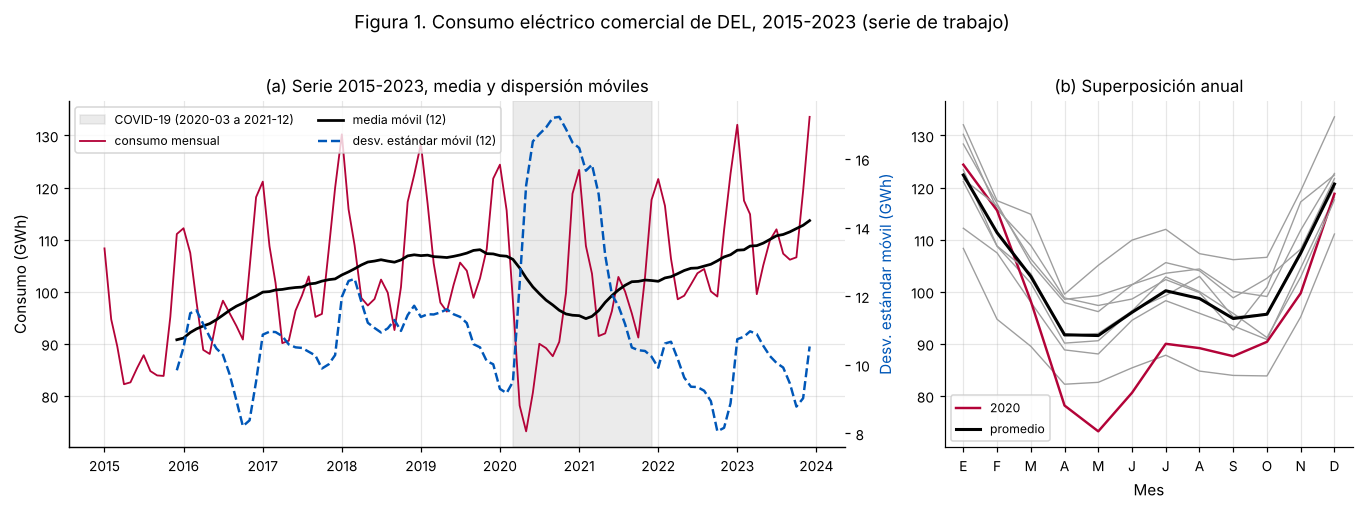

In [3]:
covid = (pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"))   # ventana del shock (Sumativa 1)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5), gridspec_kw={"width_ratios": [1.9, 1]})
ax = axes[0]
ax.axvspan(*covid, color=GRIS, alpha=0.2, label="COVID-19 (2020-03 a 2021-12)")
ax.plot(y.index, y, color=ROJO, lw=1.2, label="consumo mensual")
ax.plot(y.index, y.rolling(S).mean(), color="k", lw=1.8, label="media móvil (12)")
ax2 = ax.twinx()
ax2.plot(y.index, y.rolling(S).std(), color=AZUL, lw=1.6, ls="--", label="desv. estándar móvil (12)")
ax2.set_ylabel("Desv. estándar móvil (GWh)", color=AZUL); ax2.grid(False)
ax.set(ylabel="Consumo (GWh)", title="(a) Serie 2015-2023, media y dispersión móviles")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left", ncol=2)
for anio, g in y.groupby(y.index.year):
    axes[1].plot(g.index.month, g.values, color=ROJO if anio == 2020 else GRIS,
                 lw=1.6 if anio == 2020 else 0.9, label="2020" if anio == 2020 else None)
axes[1].plot(range(1, 13), y.groupby(y.index.month).mean(), "k", lw=2, label="promedio")
axes[1].set_xticks(range(1, 13), list("EFMAMJJASOND"))
axes[1].set(xlabel="Mes", title="(b) Superposición anual"); axes[1].legend(fontsize=8)
fig.suptitle("Figura 1. Consumo eléctrico comercial de DEL, 2015-2023 (serie de trabajo)", y=1.02)
plt.tight_layout(); plt.show()

La serie presenta **tendencia** creciente, **estacionalidad** anual con máximos en enero/diciembre y julio, un **cambio de nivel** transitorio en 2020 y una **dispersión** estable salvo durante el shock. En conjunto, son indicios de no estacionariedad.

A continuación se evalúa si la dispersión es proporcional al nivel, mediante el coeficiente de variación (CV) anual y el λ de Box y Cox (1964).

In [4]:
anual = y.groupby(y.index.year).agg(media="mean", desv="std")
anual["CV (%)"] = 100 * anual["desv"] / anual["media"]
display(anual.round(2).T)
lam, ic_lam = stats.boxcox(y.to_numpy(), alpha=0.05)[1:]          # λ de Box-Cox por máxima verosimilitud
candidatas = {"sin transformar (λ = 1)": y, "raíz cuadrada (λ = 0,5)": np.sqrt(y),
              f"Box-Cox (λ = {lam:.3f})": pd.Series(stats.boxcox(y.to_numpy(), lam), index=y.index),
              "logaritmo (λ = 0)": np.log(y)}
cv_anual = {n: (lambda g: 100 * g.std() / g.mean().abs())(v[~v.index.year.isin([2020, 2021])].groupby(lambda t: t.year))
            for n, v in candidatas.items()}                       # CV anual sin los años del shock
print(f"λ (MV) = {lam:.3f} | IC 95 %: [{ic_lam[0]:.2f}; {ic_lam[1]:.2f}] | desv. del CV anual por transformación:",
      {n: round(float(cv.std()), 3) for n, cv in cv_anual.items()})

fecha,2015,2016,2017,2018,2019,2020,2021,2022,2023
media,90.78,99.18,102.46,107.09,107.26,95.49,102.15,107.10,113.66
desv,9.84,9.51,10.28,11.72,10.02,16.48,10.24,8.88,10.54
CV (%),10.84,9.59,10.04,10.95,9.34,17.26,10.02,8.29,9.27


λ (MV) = 0.095 | IC 95 %: [-1.24; 1.46] | desv. del CV anual por transformación: {'sin transformar (λ = 1)': 0.935, 'raíz cuadrada (λ = 0,5)': 0.45, 'Box-Cox (λ = 0.095)': 0.249, 'logaritmo (λ = 0)': 0.204}


El CV anual es estable fuera del shock, y λ̂ = 0,095 está cerca de 0, aunque su IC 95 % es amplio. El logaritmo es la transformación con el CV más estable.

| Decisión | Evidencia | Consecuencia |
|---|---|---|
| Logaritmo: $z_t = \log(\text{consumo}_t)$ | λ̂ ≈ 0; menor variabilidad del CV anual | Los efectos se leen en %, y los pronósticos se retransforman con corrección de sesgo |

### 2.2 ADF, KPSS y diferenciación

ADF ($H_0$: raíz unitaria; Dickey y Fuller, 1979) y KPSS ($H_0$: estacionariedad en nivel; Kwiatkowski et al., 1992) evalúan la estacionariedad desde hipótesis complementarias, con α = 0,05. El p-valor de KPSS está acotado a [0,01; 0,10].

In [5]:
def diagnostico_estacionariedad(serie, nombre="serie", alpha=0.05, imprimir=True):
    """ADF (H0: raíz unitaria) y KPSS (H0: estacionariedad en nivel), varianza y ρ1 (adaptada de la Sesión 2)."""
    x = np.asarray(serie, dtype=float); x = x[~np.isnan(x)]
    adf_est, p_adf = adfuller(x, autolag="AIC")[:2]
    kpss_est, p_kpss = kpss(x, regression="c", nlags="auto")[:2]
    adf_ok, kpss_ok = p_adf < alpha, p_kpss > alpha
    veredicto = {(True, True): "compatible con estacionariedad", (False, False): "evidencia de no estacionariedad",
                 (True, False): "ambiguo (tendencia)", (False, True): "ambiguo: revisar ACF y varianza"}[(adf_ok, kpss_ok)]
    if imprimir:
        print(f"{nombre:<24} ADF = {adf_est:7.3f} (p = {p_adf:.4f}) | KPSS = {kpss_est:.3f} (p = {p_kpss:.3f}) → {veredicto}")
    return {"serie": nombre, "n": len(x), "ADF estad.": adf_est, "ADF p": p_adf, "KPSS estad.": kpss_est,
            "KPSS p": p_kpss, "varianza": float(np.var(x)), "ρ1": float(acf(x, nlags=1)[1]), "veredicto": veredicto}

ly = np.log(y).rename("log_consumo")                          # serie transformada
_ = diagnostico_estacionariedad(y, "Serie original (GWh)")
_ = diagnostico_estacionariedad(ly, "log(consumo)")

Serie original (GWh)     ADF =  -1.360 (p = 0.6012) | KPSS = 0.477 (p = 0.047) → evidencia de no estacionariedad
log(consumo)             ADF =  -1.694 (p = 0.4341) | KPSS = 0.469 (p = 0.049) → evidencia de no estacionariedad


En la serie original y en el logaritmo, ADF no rechaza la raíz unitaria y KPSS rechaza la estacionariedad: la evidencia conjunta indica no estacionariedad, por lo que es necesario diferenciar.

Se aplica ∇12 y luego ∇. Según el criterio de varianza (UNAB, s. f.-b; Rosas, 2026), se diferencia mientras la varianza disminuya; el peldaño 4 se sobrediferencia a propósito.

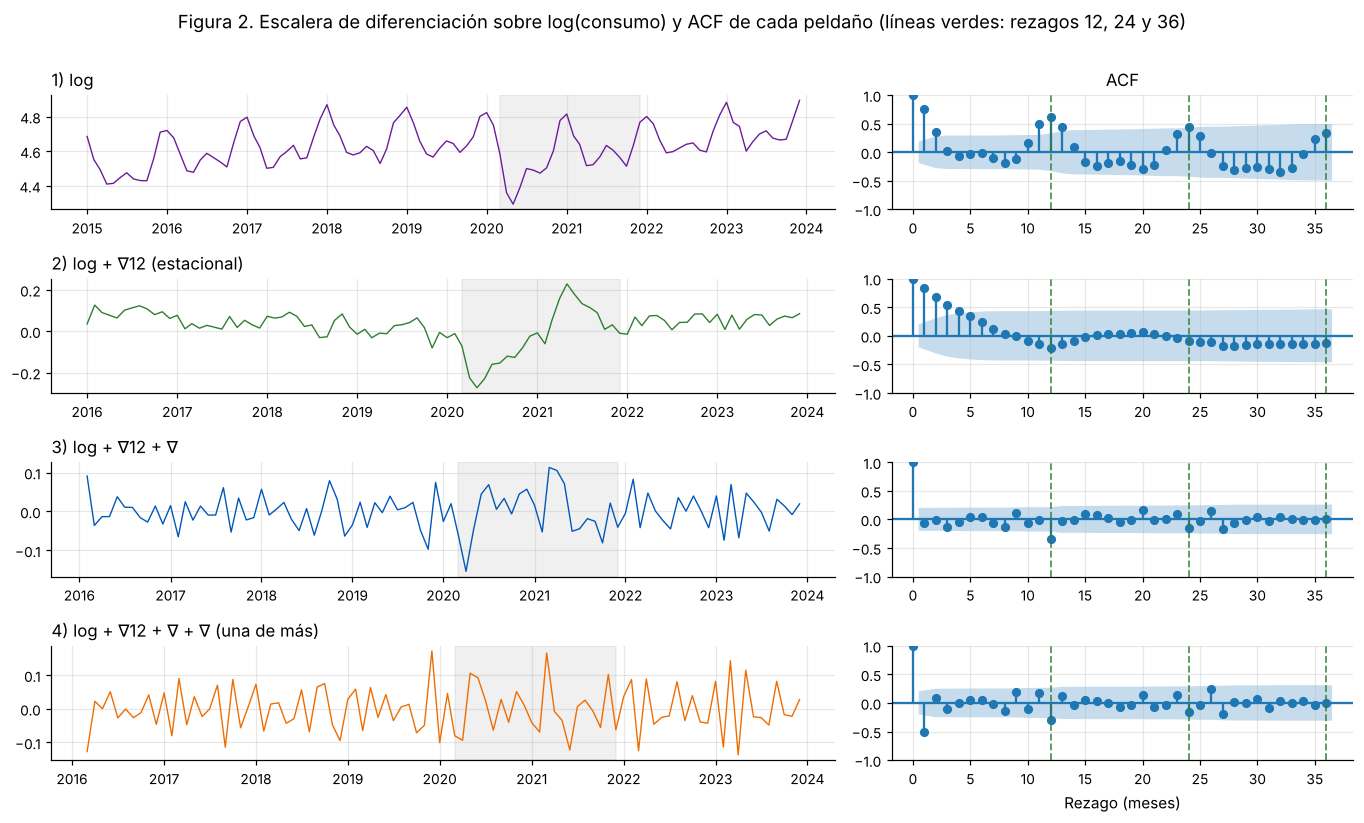

,ADF estad.,ADF p,KPSS estad.,KPSS p,varianza,ρ1,ACF(12)
serie,,,,,,,
1) log,-1.694,0.4341,0.469,0.049,1.46e-02,0.761,0.617
2) log + ∇12 (estacional),-2.859,0.0504,0.191,0.100,6.44e-03,0.832,-0.208
2b) log + ∇ (solo regular),-2.969,0.0379,0.040,0.100,6.33e-03,0.437,0.742
3) log + ∇12 + ∇,-10.411,0.0000,0.041,0.100,2.16e-03,-0.062,-0.347
4) log + ∇12 + ∇ + ∇ (una de más),-6.014,0.0000,0.178,0.100,4.54e-03,-0.510,-0.295


Varianza: peldaño 2 → 3: -66 % | peldaño 3 → 4: +110 % | peldaño 2b: ACF(24) = +0.645


In [6]:
escalera = [(ly, "1) log", MORADO), (ly.diff(S).dropna(), "2) log + ∇12 (estacional)", VERDE),
            (ly.diff(1).dropna(), "2b) log + ∇ (solo regular)", GRIS),
            (ly.diff(S).diff(1).dropna(), "3) log + ∇12 + ∇", AZUL),
            (ly.diff(S).diff(1).diff(1).dropna(), "4) log + ∇12 + ∇ + ∇ (una de más)", NARANJA)]
graf = [e for e in escalera if not e[1].startswith("2b")]      # 2b solo en la tabla
fig, axes = plt.subplots(len(graf), 2, figsize=(12.5, 7.4), gridspec_kw={"width_ratios": [1.7, 1]})
for fila, (serie, titulo, color) in enumerate(graf):
    axes[fila, 0].plot(serie.index, serie.to_numpy(), color=color, lw=0.9)
    axes[fila, 0].axvspan(*covid, color=GRIS, alpha=0.15)
    axes[fila, 0].set_title(titulo, loc="left")
    plot_acf(serie.to_numpy(), lags=36, ax=axes[fila, 1], title="ACF" if fila == 0 else "")
    for k in (12, 24, 36):
        axes[fila, 1].axvline(k, color=VERDE, ls="--", lw=1.2, alpha=0.8)
axes[-1, 1].set_xlabel("Rezago (meses)")
fig.suptitle("Figura 2. Escalera de diferenciación sobre log(consumo) y ACF de cada peldaño "
             "(líneas verdes: rezagos 12, 24 y 36)", y=1.005)
plt.tight_layout(); plt.show()

tabla_escalera = pd.DataFrame([diagnostico_estacionariedad(s_, t, imprimir=False) for s_, t, _ in escalera]).set_index("serie")
acf2b = acf(escalera[2][0], nlags=24)
tabla_escalera["ACF(12)"] = [acf(s_, nlags=12)[12] for s_, _, _ in escalera]
display(tabla_escalera.drop(columns=["n", "veredicto"])
        .style.format({"varianza": "{:.2e}", "ADF p": "{:.4f}"}, precision=3))
v2, v3, v4 = (tabla_escalera.iloc[i]["varianza"] for i in (1, 3, 4))
print(f"Varianza: peldaño 2 → 3: {100 * (v3 / v2 - 1):+.0f} % | peldaño 3 → 4: {100 * (v4 / v3 - 1):+.0f} % | "
      f"peldaño 2b: ACF(24) = {acf2b[24]:+.3f}")

Con ∇12, la evidencia es ambigua (ADF p = 0,0504 y ACF de decaimiento lento). Con solo ∇, las pruebas no rechazan la estacionariedad, pero la ACF(12) se mantiene en 0,742, porque ADF y KPSS no detectan la raíz estacional. Con ∇12 + ∇, ADF rechaza, KPSS no rechaza, desaparecen los picos estacionales y la varianza cae 66 %, hasta su mínimo. Una diferencia adicional eleva la varianza en 110 % y lleva $\rho_1$ a −0,510, lo que indica sobrediferenciación.

### 2.3 Quiebre COVID-19

Como $w_t = z_t - z_{t-1} - z_{t-12} + z_{t-13}$, cada mes del shock afecta a $w_t$ dos veces. Se cuantifica ese efecto y se modela con una intervención determinística (Box y Tiao, 1975).

In [7]:
# (a) Caída respecto del mismo mes de 2019 (%, escala log)
desv19 = pd.DataFrame({a: [100 * (ly[f"{a}-{m:02d}-01"] - ly[f"2019-{m:02d}-01"]) for m in range(1, 13)]
                       for a in (2020, 2021)}, index=list("EFMAMJJASOND")).T
display(desv19.round(1))
# (b) w_t usa z_t, z_{t-1}, z_{t-12} y z_{t-13}: observaciones afectadas por el shock
w = ly.diff(S).diff(1).dropna().rename("w")
meses_covid = pd.date_range(*covid, freq="MS")
contaminada = pd.Series([any((t - pd.DateOffset(months=k)) in meses_covid for k in (0, 1, 12, 13)) for t in w.index],
                        index=w.index)
# (c) Intervenciones determinísticas (Box y Tiao, 1975)
def indicadora(indice, inicio, fin):
    return pd.Series(((indice >= inicio) & (indice <= fin)).astype(float), index=indice)

X = pd.DataFrame({"covid": indicadora(y.index, "2020-03-01", "2021-12-01"),   # escalón del episodio
                  "agudo": indicadora(y.index, "2020-04-01", "2020-06-01")})  # fase aguda adicional
pre = SARIMAX(ly, exog=X, order=(0, 1, 0), seasonal_order=(0, 1, 0, S)).fit(disp=False)   # efecto preliminar
ly_aj = (ly - X @ pre.params[["covid", "agudo"]]).rename("log_consumo_ajustado")
w_aj = ly_aj.diff(S).diff(1).dropna().rename("w_aj")          # serie de trabajo para identificar
print(f"w_t afectadas por el shock: {contaminada.sum()} de {len(w)} ({100 * contaminada.mean():.0f} %)")
_ = diagnostico_estacionariedad(w, "w_t sin ajustar")
_ = diagnostico_estacionariedad(w_aj, "w_t ajustada")
print(f"ACF(1) de w_t: {acf(w, nlags=1)[1]:+.3f} (sin ajustar) → {acf(w_aj, nlags=1)[1]:+.3f} (ajustada)")

,E,F,M,A,M,J,J,A,S,O,N,D
2020,-3.1,-1.1,-7.2,-22.5,-27.3,-22.9,-16.0,-15.4,-12.0,-12.7,-8.2,-2.4
2021,-3.9,-7.2,-1.9,-6.8,-4.4,-5.1,-2.6,-3.9,-3.1,-11.8,-5.1,-3.4


w_t afectadas por el shock: 35 de 95 (37 %)
w_t sin ajustar          ADF = -10.411 (p = 0.0000) | KPSS = 0.041 (p = 0.100) → compatible con estacionariedad
w_t ajustada             ADF = -14.032 (p = 0.0000) | KPSS = 0.049 (p = 0.100) → compatible con estacionariedad
ACF(1) de w_t: -0.062 (sin ajustar) → -0.338 (ajustada)


El shock tiene una fase aguda en abril–junio de 2020 y otra persistente hasta 2021-12, y afecta al 37 % de $w_t$. Se modela con las indicadoras `covid` (escalón 2020-03 a 2021-12) y `agudo` (abril–junio de 2020). La estacionariedad de $w_t$ se mantiene, pero al descontar el shock la ACF(1) pasa de −0,062 a −0,338; por eso, la identificación usa $w_t$ ajustada.

| Decisión | Evidencia | Consecuencia |
|---|---|---|
| **d = 1, D = 1, s = 12** sobre log(consumo) | Único peldaño con ADF y KPSS concordantes y varianza mínima; d = 2 sobrediferencia; D = 0 deja ACF(12) = 0,742 | n = 95; los candidatos son comparables por AIC/BIC |

---
## 3. Identificación y estimación de modelos

### 3.1 ACF, PACF y modelos candidatos

Se calculan la ACF y la PACF de $w_t$ ajustada con 36 rezagos. Los rezagos 1–11 orientan *p* y *q*, y los rezagos 12, 24 y 36, *P* y *Q* (Hyndman y Athanasopoulos, 2021).

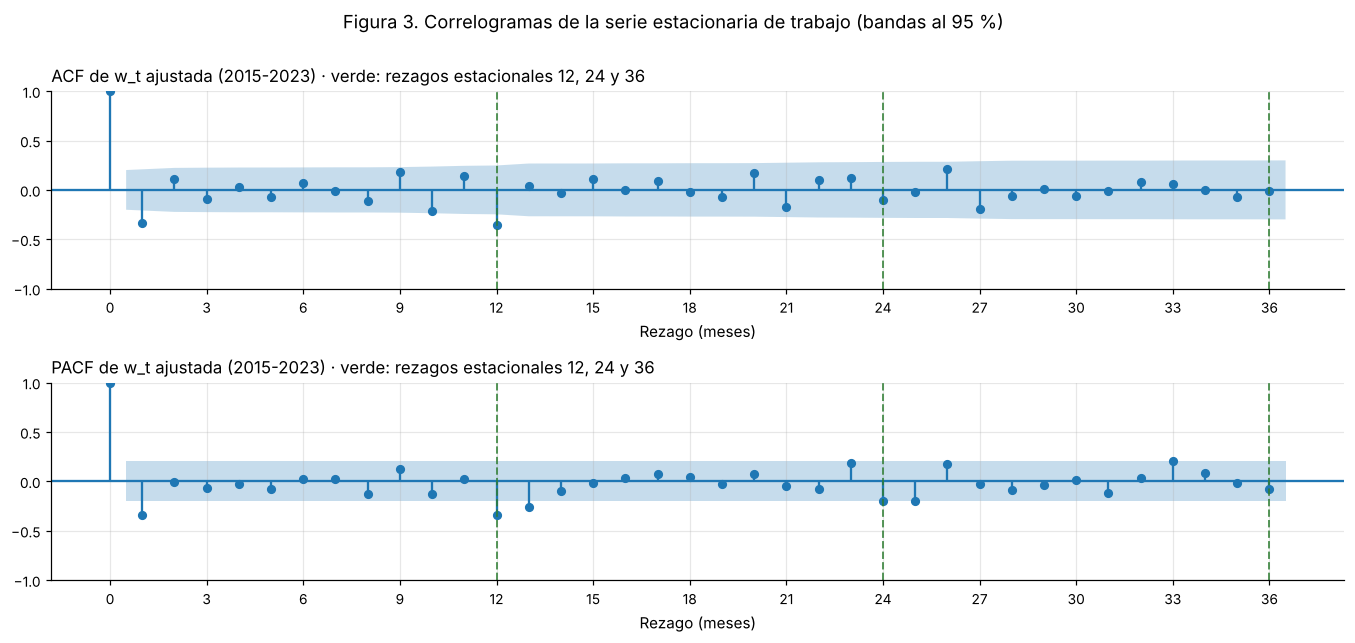

n = 95 | banda 95 % = ±0.201
ACF fuera de banda : {1: -0.338, 10: -0.213, 12: -0.356, 26: 0.207}
PACF fuera de banda: {1: -0.338, 12: -0.341, 13: -0.258, 24: -0.201, 25: -0.201, 33: 0.203}


In [8]:
n_w = len(w_aj); banda = 1.96 / np.sqrt(n_w)
fig, axes = plt.subplots(2, 1, figsize=(12.5, 5.8))
plot_acf(w_aj.to_numpy(), lags=36, ax=axes[0], title="")
plot_pacf(w_aj.to_numpy(), lags=36, ax=axes[1], method="ywm", title="")
for ax, nombre in zip(axes, ["ACF", "PACF"]):
    for k in (S, 2 * S, 3 * S):
        ax.axvline(k, color=VERDE, ls="--", lw=1.3, alpha=0.8)
    ax.set_xticks(range(0, 37, 3)); ax.set_xlabel("Rezago (meses)")
    ax.set_title(f"{nombre} de w_t ajustada (2015-2023) · verde: rezagos estacionales 12, 24 y 36", loc="left")
fig.suptitle("Figura 3. Correlogramas de la serie estacionaria de trabajo (bandas al 95 %)", y=1.0)
plt.tight_layout(); plt.show()
r_acf, r_pacf = acf(w_aj, nlags=36), pacf(w_aj, nlags=36, method="ywm")
print(f"n = {n_w} | banda 95 % = ±{banda:.3f}")
print("ACF fuera de banda :", {k: round(float(r_acf[k]), 3) for k in range(1, 37) if abs(r_acf[k]) > banda})
print("PACF fuera de banda:", {k: round(float(r_pacf[k]), 3) for k in range(1, 37) if abs(r_pacf[k]) > banda})

En el bloque regular, la ACF y la PACF solo son significativas en el rezago 1 (−0,338); los cruces en los rezagos 10 y 26, apenas sobre la banda, se atribuyen al azar. Esta firma es compatible con un MA(1) o con un AR(1). En el bloque estacional, la ACF se corta en 12 y la PACF decae en 12 y 24, lo que corresponde a un MA(1) estacional. Salvo M0, todos los candidatos incluyen las indicadoras `covid` y `agudo`.

| Modelo | Especificación | Función |
|---|---|---|
| **M1** | SARIMA(0,1,1)(0,1,1)₁₂ | Lectura directa de la ACF (MA regular y estacional) |
| **M2** | SARIMA(1,1,0)(0,1,1)₁₂ | Lectura alternativa: AR regular |
| M3 | SARIMA(1,1,1)(0,1,1)₁₂ | Contraste: término mixto |
| M4 | SARIMA(0,1,1)(1,1,0)₁₂ | Contraste: AR estacional |
| M5 | SARIMA(0,1,0)(0,1,1)₁₂ | Contraste: lectura sin ajustar el shock |
| M6 | SARIMA(1,1,1)(1,1,1)₁₂ | Contraste: sobreparametrizado |
| M0 | M1 sin intervención | Contraste de la intervención |
| M7 | ARIMA(0,1,1) + indicadoras de mes | Contraste: estacionalidad determinista (D = 0) |

### 3.2 Estimación

Las variables `covid` y `agudo` se incorporan como **intervenciones determinísticas** asociadas a un episodio identificado previamente. No corresponden a covariables predictivas externas; la estructura dinámica del error continúa siendo SARIMA. Se mantiene un modelo sin intervención (M0) como contraste.

Los modelos se estiman por máxima verosimilitud con 2015–2022. La tabla reporta la convergencia (50 y 200 iteraciones), el módulo mínimo de las raíces, los coeficientes con su p-valor (prueba de razón de verosimilitud, LR, para ARMA; Wald para la intervención), el AIC y el BIC.

In [9]:
# --- Partición cronológica: estimación 2015-2022 · validación 2023 (2024 sellado) ---
H = 12                                                        # horizonte = compromiso anual de DEL
y_est, y_val = y[:"2022-12-01"], y["2023-01-01":]
ly_est, ly_val = ly[:"2022-12-01"], ly["2023-01-01":]
MESES = pd.get_dummies(y.index.month, prefix="mes", dtype=float).iloc[:, 1:].set_index(y.index)
CANDIDATOS = {   # nombre: (orden, orden estacional, regresores)
    "M1 (0,1,1)(0,1,1)": ((0, 1, 1), (0, 1, 1, S), X),
    "M2 (1,1,0)(0,1,1)": ((1, 1, 0), (0, 1, 1, S), X),
    "M3 (1,1,1)(0,1,1)": ((1, 1, 1), (0, 1, 1, S), X),
    "M4 (0,1,1)(1,1,0)": ((0, 1, 1), (1, 1, 0, S), X),
    "M5 (0,1,0)(0,1,1)": ((0, 1, 0), (0, 1, 1, S), X),
    "M6 (1,1,1)(1,1,1)": ((1, 1, 1), (1, 1, 1, S), X),
    "M0 (0,1,1)(0,1,1) sin interv.": ((0, 1, 1), (0, 1, 1, S), None),
    "M7 (0,1,1) + dummies mes": ((0, 1, 1), (0, 0, 0, 0), pd.concat([X, MESES], axis=1)),
}

def estimar(serie, orden, orden_est, exog=None, maxiter=200):
    """Estimación por MV; devuelve el ajuste y el número de avisos de convergencia."""
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter("always")
        fit = SARIMAX(serie, exog=exog, order=orden, seasonal_order=orden_est).fit(disp=False, maxiter=maxiter)
    return fit, sum(issubclass(a.category, ConvergenceWarning) for a in avisos)

def nombres_arma(fit):
    return [p for p in fit.param_names if p.startswith(("ar.", "ma."))]

def sin_parametro(orden, orden_est, param):
    """Órdenes del modelo restringido (param = 0) para la prueba de razón de verosimilitud."""
    (p, d, q), (P, D, Q, s) = orden, orden_est
    rez = {k: list(range(1, n + 1)) for k, n in {"ar": p, "ma": q, "ar.S": P, "ma.S": Q}.items()}
    tipo, rezago = param.rsplit(".L", 1)
    rez[tipo].remove(int(rezago) // (s if ".S" in tipo else 1))
    norm = lambda l: len(l) if l == list(range(1, len(l) + 1)) else l
    return (norm(rez["ar"]), d, norm(rez["ma"])), (norm(rez["ar.S"]), D, norm(rez["ma.S"]), s)

ajustes, filas = {}, []
for nombre, (orden, orden_est, Xc) in CANDIDATOS.items():
    Xe = None if Xc is None else Xc.loc[ly_est.index]
    fit50, av50 = estimar(ly_est, orden, orden_est, Xe, maxiter=50)          # valor por defecto
    fit, av = estimar(ly_est, orden, orden_est, Xe, maxiter=200)
    ajustes[nombre] = fit
    fila = {"modelo": nombre, "k": len(fit.params) - 1,
            "conv. 50 / 200 it.": f"{'sí' if fit50.mle_retvals.get('converged', True) and av50 == 0 else 'NO'} / "
                                  f"{'sí' if fit.mle_retvals.get('converged', True) and av == 0 else 'NO'}",
            "|raíz| mín": np.concatenate([np.abs(fit.arroots), np.abs(fit.maroots)]).min()}
    for p in ["covid", "agudo"] + nombres_arma(fit):              # coeficiente y p-valor (LR para ARMA, Wald para X)
        if p not in fit.param_names:
            continue
        if p.startswith(("ar.", "ma.")):
            restr, _ = estimar(ly_est, *sin_parametro(orden, orden_est, p), Xe)
            pv = stats.chi2.sf(max(2 * (fit.llf - restr.llf), 0), 1)
        else:
            pv = fit.pvalues[p]
        fila[p] = f"{fit.params[p]:+.3f} ({pv:.3f})"
    fila.update({"AIC": fit.aic, "BIC": fit.bic, "n efectivo": int(fit.nobs_effective)})
    filas.append(fila)
tabla_ajuste = pd.DataFrame(filas).set_index("modelo")
cols_par = [c for c in ["covid", "agudo", "ar.L1", "ma.L1", "ar.S.L12", "ma.S.L12"] if c in tabla_ajuste]
display(tabla_ajuste[["k", "conv. 50 / 200 it.", "|raíz| mín"] + cols_par + ["AIC", "BIC"]]
        .fillna("—").round({"|raíz| mín": 4, "AIC": 2, "BIC": 2}).rename(index=lambda m: m.split()[0]))
m1 = ajustes["M1 (0,1,1)(0,1,1)"]
alt = m1.model.fit(disp=False, maxiter=200, cov_type="approx")      # covarianza alternativa (Hessiano numérico)
print(f"M1 · Θ = {m1.params['ma.S.L12']:+.4f} | e.e. OPG = {m1.bse['ma.S.L12']:.3f} (p Wald = {m1.pvalues['ma.S.L12']:.3f}) | "
      f"e.e. Hessiano = {alt.bse['ma.S.L12']:.3f} (p = {alt.pvalues['ma.S.L12']:.4f}) | p Wald de σ² (OPG) = {m1.pvalues['sigma2']:.3f}")

,k,conv. 50 / 200 it.,|raíz| mín,covid,agudo,ar.L1,ma.L1,ar.S.L12,ma.S.L12,AIC,BIC
modelo,,,,,,,,,,,
M1,4,sí / sí,1.0027,-0.058 (0.000),-0.130 (0.000),—,-0.463 (0.000),—,-0.969 (0.000),-331.33,-319.24
M2,4,sí / sí,1.0013,-0.051 (0.001),-0.130 (0.000),-0.425 (0.000),—,—,-0.984 (0.000),-330.04,-317.95
M3,5,sí / sí,1.0054,-0.058 (0.000),-0.131 (0.000),-0.066 (0.769),-0.420 (0.241),—,-0.938 (0.000),-329.42,-314.91
M4,4,sí / sí,1.0580,-0.069 (0.000),-0.138 (0.000),—,-0.557 (0.000),-0.509 (0.000),—,-312.06,-299.97
M5,3,sí / sí,1.0045,-0.043 (0.006),-0.102 (0.000),—,—,—,-0.948 (0.000),-317.71,-308.03
M6,6,NO / sí,1.0041,-0.058 (0.000),-0.133 (0.000),-0.162 (0.514),-0.355 (0.160),-0.088 (0.410),-0.953 (0.000),-328.10,-311.17
M0,2,sí / sí,1.0022,—,—,—,-0.054 (0.623),—,-0.975 (0.000),-298.03,-290.77
M7,14,sí / sí,2.3031,-0.058 (0.000),-0.128 (0.000),—,-0.434 (0.000),—,—,-400.24,-361.93


M1 · Θ = -0.9686 | e.e. OPG = 1.404 (p Wald = 0.490) | e.e. Hessiano = 0.143 (p = 0.0000) | p Wald de σ² (OPG) = 0.472


**M1 y M2** convergen y todos sus coeficientes son significativos: θ₁ = −0,463 en M1 y φ₁ = −0,425 en M2, con `covid` y `agudo` negativos (cerca de −6 % y un −12 % adicional). Por eso son los candidatos principales. Todas las raíces de los componentes ARMA superan 1 en módulo, por lo que la parte AR es estacionaria y la parte MA es invertible una vez aplicada la diferenciación definida por d = 1 y D = 1.

Ningún contraste mejora a M1. M6 no converge con 50 iteraciones (se reformuló con 200) y, al igual que M3, agrega parámetros no significativos; en M0, θ₁ deja de ser significativo. En todos los modelos, Θ₁ ≈ −1: cerca de ese límite, el p de Wald con covarianza OPG no es fiable (también σ² aparece como no significativa), pero el Hessiano numérico y la LR confirman su significancia (p < 0,001). Este valor sugiere una estacionalidad casi determinista, que se contrasta con M7.

---
## 4. Selección y comparación de modelos

Valores menores de AIC, AICc y BIC indican un mejor equilibrio entre ajuste y complejidad, siempre que los modelos se estimen sobre la misma muestra y escala (Burnham y Anderson, 2004); por ello, M7 (D = 0) solo se evalúa fuera de muestra. La partición es cronológica: todos los modelos pronostican 2023 (h = 12) desde 2022-12 y se comparan con el naive estacional y el naive estacional con deriva. La media se corrige por sesgo ($e^{\hat z + \sigma_h^2/2}$), y las métricas son ME, RMSE, MAPE y MASE (Hyndman y Koehler, 2006).

In [10]:
# --- Validación 2023: mismo periodo para todos, métricas en GWh y referencias ingenuas ---
def metricas(real, pred, denom_mase):
    real, pred = np.asarray(real, float), np.asarray(pred, float); e = real - pred
    return {"ME": e.mean(), "RMSE": np.sqrt(np.mean(e ** 2)), "MAPE (%)": 100 * np.mean(np.abs(e / real)),
            "MASE": np.mean(np.abs(e)) / denom_mase}

def pronosticar(fit, exog_futuro=None, pasos=H):
    """Pronóstico retransformado a GWh: media con corrección de sesgo, mediana e IC 95 %."""
    f = fit.get_forecast(steps=pasos, exog=exog_futuro)
    m, v, ic = np.asarray(f.predicted_mean), np.asarray(f.var_pred_mean), np.exp(np.asarray(f.conf_int()))
    return {"media": np.exp(m + v / 2), "mediana": np.exp(m), "inferior": ic[:, 0], "superior": ic[:, 1]}

denom_mase = np.mean(np.abs(y_est.to_numpy()[S:] - y_est.to_numpy()[:-S]))   # naive estacional en 2015-2022
naive_est = y_est.to_numpy()[-S:]                                            # mismo mes de 2022
g_medio = np.mean(y_est.to_numpy()[S:] / y_est.to_numpy()[:-S] - 1)          # crecimiento interanual medio
naive_deriva = naive_est * (1 + g_medio)
filas, pronosticos = [], {}
for nombre, fit in ajustes.items():
    Xc = CANDIDATOS[nombre][2]
    pr = pronosticos[nombre] = pronosticar(fit, None if Xc is None else Xc.loc[ly_val.index])
    m = metricas(y_val, pr["media"], denom_mase)
    m["RMSE sin corregir"] = metricas(y_val, pr["mediana"], denom_mase)["RMSE"]
    m["cobertura IC95 (%)"] = 100 * np.mean((y_val >= pr["inferior"]) & (y_val <= pr["superior"]))
    filas.append(pd.Series(m, name=nombre))
for nombre, pred in [("Naive estacional", naive_est), ("Naive estacional con deriva", naive_deriva)]:
    filas.append(pd.Series(metricas(y_val, pred, denom_mase), name=f"— {nombre}"))
tabla_val = pd.DataFrame(filas)
print(f"Deriva: {100 * g_medio:.2f} % anual | M1: RMSE 2023 corregido = {tabla_val.iloc[0]['RMSE']:.2f} GWh, "
      f"sin corregir = {tabla_val.iloc[0]['RMSE sin corregir']:.2f} GWh")

Deriva: 2.77 % anual | M1: RMSE 2023 corregido = 5.71 GWh, sin corregir = 5.82 GWh


**Origen móvil.** El pronóstico a 12 meses se repite desde 13 orígenes posteriores al shock, con ventana expansiva (Tashman, 2000).

In [11]:
# --- Origen móvil: 13 orígenes posteriores al shock, ventana expansiva, RMSE a 12 meses ---
def validacion_origen_movil(orden, orden_est, exog, primer_origen, h=H):
    errores, avisos = [], 0
    for t0 in range(primer_origen, len(ly) - h + 1):
        Xa = None if exog is None else exog.iloc[:t0]
        Xb = None if exog is None else exog.iloc[t0:t0 + h]
        fit, av = estimar(ly.iloc[:t0], orden, orden_est, Xa); avisos += av
        f = fit.get_forecast(steps=h, exog=Xb)
        pred = np.exp(np.asarray(f.predicted_mean) + np.asarray(f.var_pred_mean) / 2)
        errores.append(np.sqrt(np.mean((y.iloc[t0:t0 + h].to_numpy() - pred) ** 2)))
    return np.array(errores), avisos

T0 = len(ly[:"2021-12-01"])                                   # primer origen: diciembre de 2021
filas_rom, avisos_om = [], {}
for nombre, (orden, orden_est, Xc) in CANDIDATOS.items():
    e, avisos_om[nombre.split()[0]] = validacion_origen_movil(orden, orden_est, Xc, T0)
    filas_rom.append({"modelo": nombre, "RMSE medio": e.mean(), "desv. entre orígenes": e.std()})
err_ne, err_nd = [], []
for t0 in range(T0, len(ly) - H + 1):
    hist, real = y.iloc[:t0].to_numpy(), y.iloc[t0:t0 + H].to_numpy()
    gg = np.mean(hist[S:] / hist[:-S] - 1)
    err_ne.append(np.sqrt(np.mean((real - hist[-S:]) ** 2)))
    err_nd.append(np.sqrt(np.mean((real - hist[-S:] * (1 + gg)) ** 2)))
for nombre, e in [("— Naive estacional", err_ne), ("— Naive estacional con deriva", err_nd)]:
    filas_rom.append({"modelo": nombre, "RMSE medio": np.mean(e), "desv. entre orígenes": np.std(e)})
tabla_rom = pd.DataFrame(filas_rom).set_index("modelo").sort_values("RMSE medio")
print(f"{len(err_ne)} orígenes ({ly.index[T0 - 1]:%Y-%m} a {ly.index[len(ly) - H - 1]:%Y-%m}) | "
      f"avisos de convergencia: {avisos_om}")

13 orígenes (2021-12 a 2022-12) | avisos de convergencia: {'M1': 0, 'M2': 0, 'M3': 0, 'M4': 0, 'M5': 0, 'M6': 1, 'M0': 2, 'M7': 0}


**Tabla comparativa.** «23» = validación 2023; OM = origen móvil (RMSE medio y DE entre orígenes); Cob. = % de meses de 2023 dentro del IC 95 %.

,k,AIC,BIC,AICc,ΔAIC,ΔBIC,ME 23,RMSE 23,MAPE 23,MASE 23,Cob. 23,RMSE OM,DE OM
modelo,,,,,,,,,,,,,
M1,4,-331.33,-319.24,-330.82,0.00,0.00,5.20,5.71,4.60,0.80,100.00,3.73,1.52
M2,4,-330.04,-317.95,-329.53,1.29,1.29,5.64,6.11,5.00,0.87,100.00,3.67,1.10
M3,5,-329.42,-314.91,-328.64,1.91,4.33,5.25,5.76,4.65,0.81,100.00,3.91,1.89
M4,4,-312.06,-299.97,-311.55,19.27,19.27,5.32,5.97,4.64,0.82,100.00,4.11,1.46
M5,3,-317.71,-308.03,-317.40,13.63,11.21,6.73,7.12,5.96,1.04,100.00,4.17,1.49
M6,6,-328.10,-311.17,-326.99,3.23,8.07,5.16,5.69,4.58,0.79,91.67,3.82,1.86
M0,2,-298.03,-290.77,-297.88,33.30,28.46,6.57,7.07,5.85,1.01,100.00,4.59,1.37
M7,14,-400.24,-361.93,NaN,NaN,NaN,6.83,7.35,6.03,1.05,75.00,4.47,1.20
— Naive estacional,<NA>,NaN,NaN,NaN,NaN,NaN,6.56,7.30,5.67,1.01,NaN,6.57,0.40


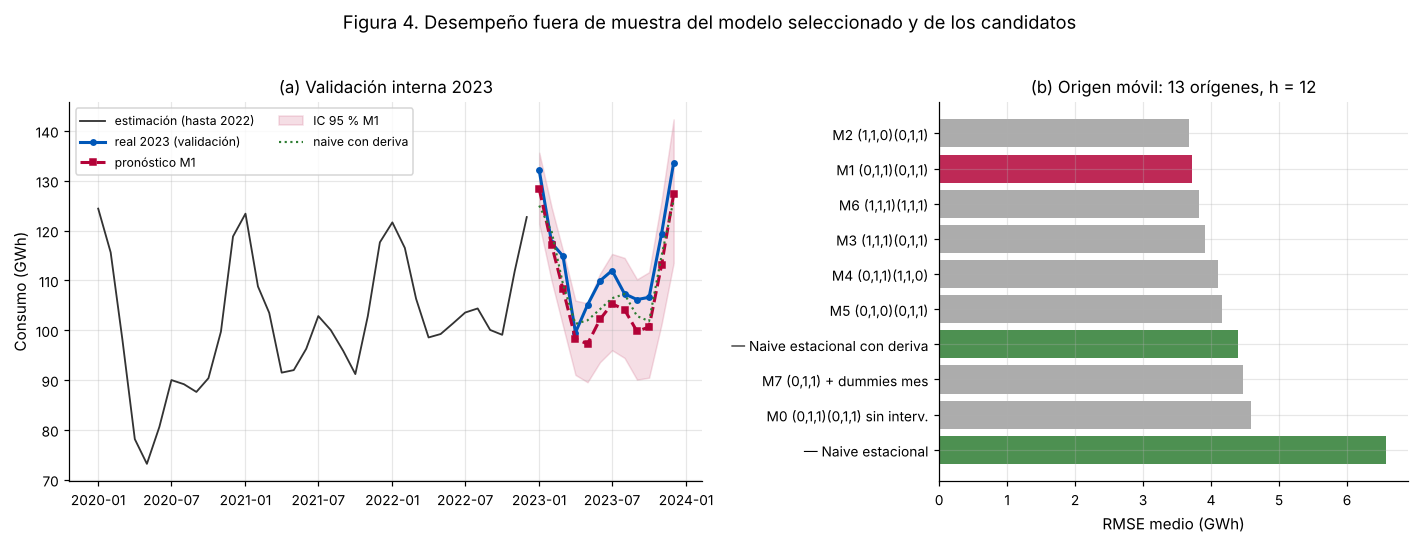

In [12]:
MEJOR = "M1 (0,1,1)(0,1,1)"
comparables = tabla_ajuste[(tabla_ajuste["n efectivo"] == tabla_ajuste.loc[MEJOR, "n efectivo"])   # excluye M7 (D = 0)
                           & tabla_ajuste["conv. 50 / 200 it."].str.endswith("sí")].copy()
n_ef, k_ = comparables["n efectivo"], comparables["k"]
comparables["AICc"] = comparables["AIC"] + 2 * k_ * (k_ + 1) / (n_ef - k_ - 1)
comparables["ΔAIC"] = comparables["AIC"] - comparables["AIC"].min()
comparables["ΔBIC"] = comparables["BIC"] - comparables["BIC"].min()
resumen = (tabla_ajuste[["k", "AIC", "BIC"]].join(comparables[["AICc", "ΔAIC", "ΔBIC"]])
           .join(tabla_val[["ME", "RMSE", "MAPE (%)", "MASE", "cobertura IC95 (%)"]], how="outer")
           .join(tabla_rom[["RMSE medio", "desv. entre orígenes"]], how="outer")
           .reindex(list(CANDIDATOS) + ["— Naive estacional", "— Naive estacional con deriva"]))
resumen["k"] = resumen["k"].astype("Int64")
resumen.columns = ["k", "AIC", "BIC", "AICc", "ΔAIC", "ΔBIC", "ME 23", "RMSE 23", "MAPE 23", "MASE 23",
                   "Cob. 23", "RMSE OM", "DE OM"]
display(resumen.round(2).rename(index=lambda m: m.split()[0] if m[0] == "M" else m.replace("estacional ", "")))

pr = pronosticos[MEJOR]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1.35, 1]})
ax = axes[0]
ax.plot(y_est["2020-01-01":].index, y_est["2020-01-01":], color="#333333", lw=1.2, label="estimación (hasta 2022)")
ax.plot(y_val.index, y_val, color=AZUL, lw=2, marker="o", ms=3.5, label="real 2023 (validación)")
ax.plot(y_val.index, pr["media"], color=ROJO, lw=2, ls="--", marker="s", ms=3.5, label="pronóstico M1")
ax.fill_between(y_val.index, pr["inferior"], pr["superior"], color=ROJO, alpha=0.13, label="IC 95 % M1")
ax.plot(y_val.index, naive_deriva, color=VERDE, lw=1.4, ls=":", label="naive con deriva")
ax.set(ylabel="Consumo (GWh)", title="(a) Validación interna 2023")
ax.legend(fontsize=8, loc="upper left", ncol=2)
orden_b = tabla_rom["RMSE medio"]
colores = [ROJO if m == MEJOR else (VERDE if m.startswith("—") else GRIS) for m in orden_b.index]
axes[1].barh(range(len(orden_b)), orden_b, color=colores, alpha=0.85)
axes[1].set_yticks(range(len(orden_b)), list(orden_b.index), fontsize=9)
axes[1].invert_yaxis()
axes[1].set(xlabel="RMSE medio (GWh)", title=f"(b) Origen móvil: {len(err_ne)} orígenes, h = 12")
fig.suptitle("Figura 4. Desempeño fuera de muestra del modelo seleccionado y de los candidatos", y=1.02)
plt.tight_layout(); plt.show()

**Validación.** M1 obtiene el mejor AIC, AICc y BIC. En 2023 es el SARIMA elegible con menor error, pero todos subestiman el alza de ese año (ME positivo). En la Figura 4a, el pronóstico de M1 queda bajo los valores reales en los 12 meses, aunque dentro del IC 95 %, y el naive con deriva logra un menor RMSE.

**M1 frente a M2 y las referencias.** En el origen móvil, el resultado se invierte: M1 y M2 superan a ambas referencias naive (Figura 4b), y su diferencia (1,4 %) es menor que la variabilidad entre orígenes. M7, M0 y las referencias naive muestran un desempeño inferior; solo M6 y M0 registraron avisos de convergencia en los reajustes.

**Decisión.** Se selecciona M1, no solo por el AIC, sino porque combina el mejor ajuste penalizado, un RMSE de origen móvil 15 % menor que el del naive con deriva, parámetros significativos y coherencia con la ACF. M2 queda como alternativa.

---
## 5. Diagnóstico de residuos y validación de supuestos

### 5.1 Reestimación y diagnóstico gráfico

M1 se reestima con 2015–2023 y, como en el notebook docente, se descartan los primeros $d + D\cdot s = 13$ residuos, que corresponden al arranque del filtro de Kalman.

In [13]:
modelo_final, av_final = estimar(ly, CANDIDATOS[MEJOR][0], CANDIDATOS[MEJOR][1], X)   # reestimación 2015-2023
cambio = 100 * (modelo_final.params / ajustes[MEJOR].params - 1)
print("Coeficientes 2015-2023 (cambio vs. 2015-2022):", " | ".join(
      f"{k} = {modelo_final.params[k]:+.4f} ({cambio[k]:+.1f} %)" for k in modelo_final.param_names[:-1]),
      f"| avisos: {av_final} | p Wald de Θ = {modelo_final.pvalues['ma.S.L12']:.3f}")
lr = {p: 2 * (modelo_final.llf - estimar(ly, *sin_parametro(CANDIDATOS[MEJOR][0], CANDIDATOS[MEJOR][1], p), X)[0].llf)
      for p in nombres_arma(modelo_final)}
efe = np.exp(modelo_final.params[["covid", "agudo"]].cumsum()) - 1
print("LR:", {p: f"p = {stats.chi2.sf(v, 1):.2e}" for p, v in lr.items()},
      f"| efecto del shock: {100 * efe['covid']:.1f} % (episodio) y {100 * efe['agudo']:.1f} % (abril-junio 2020)")

m_arma = len(nombres_arma(modelo_final))      # θ1 y Θ1: grados de libertad descontados en Ljung-Box
n_descartar = 1 + 1 * S                       # d + D·s residuos de arranque del filtro de Kalman
res_todos = pd.Series(np.asarray(modelo_final.resid), index=ly.index, name="residuos")
res = res_todos.iloc[n_descartar:]
print(f"Residuos 1 y 13 (arranque): {res_todos.iloc[0]:.3f} y {res_todos.iloc[12]:.3f} | desv. estándar con arranque: "
      f"{res_todos.std():.4f}, sin arranque: {res.std():.4f} | residuos usados: {len(res)}")

Coeficientes 2015-2023 (cambio vs. 2015-2022): covid = -0.0603 (+4.1 %) | agudo = -0.1328 (+1.8 %) | ma.L1 = -0.4871 (+5.2 %) | ma.S.L12 = -0.9745 (+0.6 %) | avisos: 0 | p Wald de Θ = 0.524


LR: {'ma.L1': 'p = 3.40e-06', 'ma.S.L12': 'p = 8.87e-12'} | efecto del shock: -5.9 % (episodio) y -17.6 % (abril-junio 2020)
Residuos 1 y 13 (arranque): 4.685 y -2.333 | desv. estándar con arranque: 0.5071, sin arranque: 0.0307 | residuos usados: 95


Los coeficientes cambian menos de 6 %, y la LR confirma θ₁ y Θ₁. El shock equivale a −5,9 % en el episodio y a −17,6 % en abril–junio de 2020. El modelo final es:

$$(1-B)(1-B^{12})\big(\log\text{consumo}_t + 0{,}060\,\texttt{covid}_t + 0{,}133\,\texttt{agudo}_t\big) = (1 - 0{,}487B)(1 - 0{,}975B^{12})\,\varepsilon_t$$

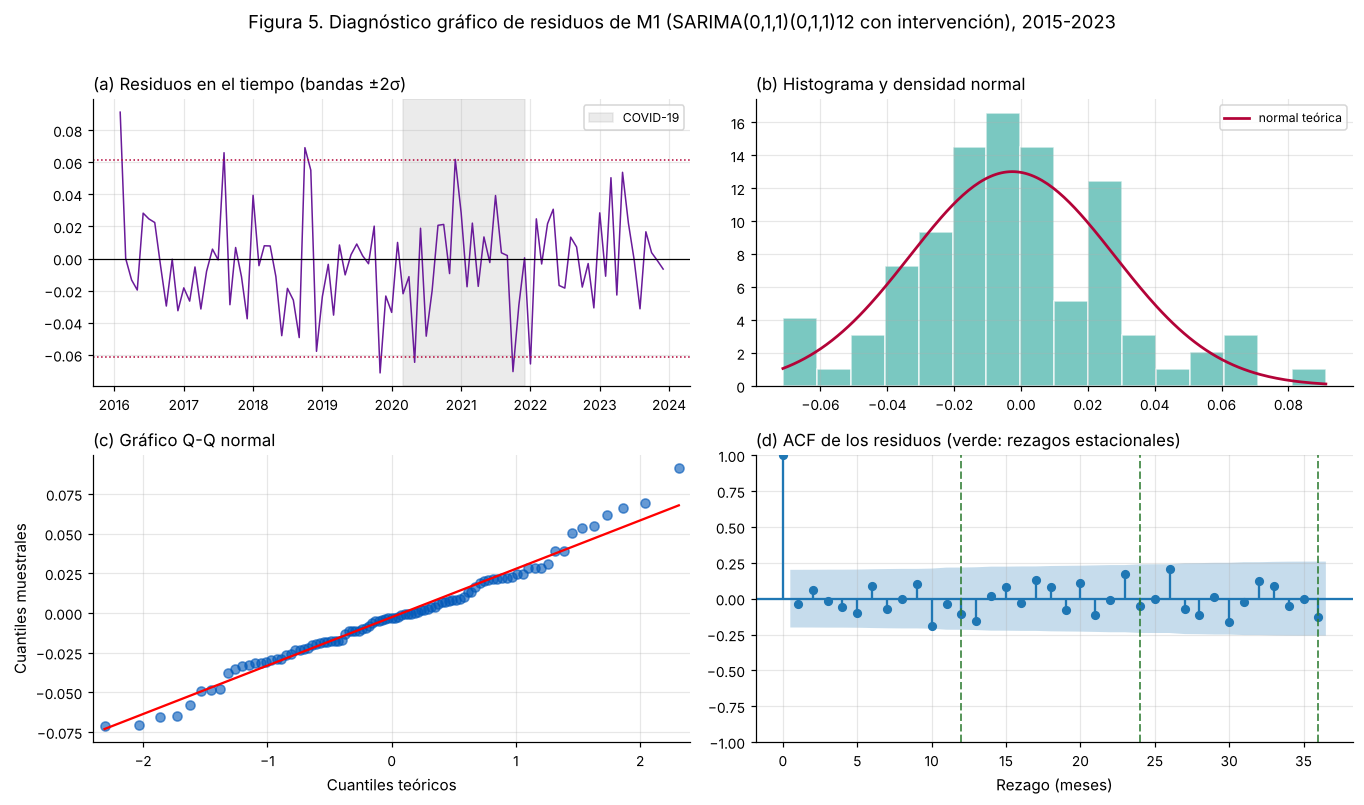

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.2))
axes[0, 0].axvspan(*covid, color=GRIS, alpha=0.2, label="COVID-19")
axes[0, 0].plot(res.index, res, color=MORADO, lw=1.0)
axes[0, 0].axhline(0, color="k", lw=0.8)
for sgn in (1, -1):
    axes[0, 0].axhline(sgn * 2 * res.std(), color=ROJO, ls=":", lw=1)
axes[0, 0].set_title("(a) Residuos en el tiempo (bandas ±2σ)", loc="left"); axes[0, 0].legend(fontsize=8)
axes[0, 1].hist(res, bins=16, density=True, color="#4db6ac", alpha=0.75, edgecolor="white")
xx = np.linspace(res.min(), res.max(), 200)
axes[0, 1].plot(xx, stats.norm.pdf(xx, res.mean(), res.std()), color=ROJO, lw=1.8, label="normal teórica")
axes[0, 1].set_title("(b) Histograma y densidad normal", loc="left"); axes[0, 1].legend(fontsize=8)
sm.qqplot(res.to_numpy(), line="s", ax=axes[1, 0], markerfacecolor=AZUL, markeredgecolor=AZUL, alpha=0.6)
axes[1, 0].set_title("(c) Gráfico Q-Q normal", loc="left")
axes[1, 0].set(xlabel="Cuantiles teóricos", ylabel="Cuantiles muestrales")
plot_acf(res.to_numpy(), lags=36, ax=axes[1, 1], title="")
for k in (12, 24, 36):
    axes[1, 1].axvline(k, color=VERDE, ls="--", lw=1.3, alpha=0.8)
axes[1, 1].set_title("(d) ACF de los residuos (verde: rezagos estacionales)", loc="left")
axes[1, 1].set_xlabel("Rezago (meses)")
fig.suptitle("Figura 5. Diagnóstico gráfico de residuos de M1 (SARIMA(0,1,1)(0,1,1)12 con intervención), 2015-2023", y=1.01)
plt.tight_layout(); plt.show()

Los residuos fluctúan en torno a cero, sin cambios visibles de amplitud. El histograma y el gráfico Q-Q se aproximan a la normal, con una leve cola superior, y la ACF no muestra rezagos significativos, tampoco en 12, 24 y 36.

### 5.2 Pruebas formales

Se aplican Ljung-Box con gl = K − 2 (Ljung y Box, 1978), *t* de Student, ARCH-LM (Engle, 1982), Goldfeld y Quandt (1965), Levene, Shapiro y Wilk (1965) y Jarque y Bera (1987).

In [15]:
def bateria(res, m_arma, K=(6, 12, 18, 24, 36)):
    """Ljung-Box, t de Student, ARCH-LM, Goldfeld-Quandt, Levene, Shapiro-Wilk y Jarque-Bera."""
    lb = acorr_ljungbox(res, lags=list(K), model_df=m_arma, return_df=True)
    en_covid = res.index.isin(meses_covid)
    return {"lb": lb, "t": (lambda r: (r.statistic, r.pvalue))(stats.ttest_1samp(res, 0.0)), "arch": het_arch(res.to_numpy(), nlags=12)[:2],
            "gq": het_goldfeldquandt(res.to_numpy(), np.ones((len(res), 1)), split=0.5, drop=0.1, alternative="two-sided")[:2],
            "levene": stats.levene(res[en_covid], res[~en_covid])[:2], "sw": stats.shapiro(res)[:2],
            "jb": stats.jarque_bera(res)[:2], "curt": stats.kurtosis(res)}

b = bateria(res, m_arma)
filas = [(f"Ljung-Box K = {K} (gl = {K - m_arma})", "ρ1 = … = ρK = 0", r.lb_stat, r.lb_pvalue)
         for K, r in b["lb"].iterrows()]
filas += [("t de Student", "media = 0", *b["t"]), ("ARCH-LM (12 rezagos)", "sin efecto ARCH", *b["arch"]),
          ("Goldfeld-Quandt", "σ² igual en mitades", *b["gq"]),
          ("Levene", "σ² igual COVID / resto", *b["levene"]),
          ("Shapiro-Wilk", "normalidad", *b["sw"]), ("Jarque-Bera", "normalidad", *b["jb"])]
pruebas = pd.DataFrame(filas, columns=["prueba", "H0", "estadístico", "p-valor"]).set_index("prueba")
pruebas["decisión (5 %)"] = np.where(pruebas["p-valor"] > 0.05, "no rechaza", "RECHAZA")
display(pruebas.round(4))
lb_mal = acorr_ljungbox(res, lags=[12], model_df=0, return_df=True)["lb_pvalue"].iloc[0]
print(f"Ljung-Box K = 12 sin corregir gl: p = {lb_mal:.4f} | curtosis (exceso) = {b['curt']:+.3f} | "
      f"|residuo| > 2σ: {int((res.abs() > 2 * res.std()).sum())} de {len(res)} (esperado ≈ {0.0455 * len(res):.1f})")

,H0,estadístico,p-valor,decisión (5 %)
prueba,,,,
Ljung-Box K = 6 (gl = 4),ρ1 = … = ρK = 0,2.8060,0.5908,no rechaza
Ljung-Box K = 12 (gl = 10),ρ1 = … = ρK = 0,9.8722,0.4518,no rechaza
Ljung-Box K = 18 (gl = 16),ρ1 = … = ρK = 0,16.2397,0.4364,no rechaza
Ljung-Box K = 24 (gl = 22),ρ1 = … = ρK = 0,24.0475,0.3447,no rechaza
Ljung-Box K = 36 (gl = 34),ρ1 = … = ρK = 0,42.7989,0.1432,no rechaza
t de Student,media = 0,-0.8302,0.4085,no rechaza
ARCH-LM (12 rezagos),sin efecto ARCH,8.5484,0.7409,no rechaza
Goldfeld-Quandt,σ² igual en mitades,0.7795,0.4327,no rechaza
Levene,σ² igual COVID / resto,0.2039,0.6526,no rechaza


Ljung-Box K = 12 sin corregir gl: p = 0.6272 | curtosis (exceso) = +0.565 | |residuo| > 2σ: 8 de 95 (esperado ≈ 4.3)


Ninguna prueba rechaza $H_0$ con α = 0,05: no se detecta evidencia significativa de autocorrelación remanente, sesgo, heterocedasticidad condicional, cambio de varianza ni desviación de la normalidad. Corregir los grados de libertad de Ljung-Box hace la prueba más exigente (en K = 12, p = 0,452, frente a 0,627 sin corregir).

### 5.3 Contraste sin intervención

Se repite el diagnóstico para M0.

In [16]:
# --- Contraste: mismo diagnóstico para M0 (sin intervención), estimado con 2015-2023 ---
m0, _ = estimar(ly, (0, 1, 1), (0, 1, 1, S), None)
res0 = pd.Series(np.asarray(m0.resid), index=ly.index).iloc[n_descartar:]
b0 = bateria(res0, len(nombres_arma(m0)))
fila_c = lambda mod, bb, r: [mod.aic, mod.params["ma.L1"], mod.pvalues["ma.L1"], bb["lb"].loc[12, "lb_pvalue"],
                              bb["sw"][1], bb["jb"][1], bb["arch"][1], bb["levene"][1], r.min(), r.std()]
display(pd.DataFrame({"M0 (sin interv.)": fila_c(m0, b0, res0), "M1 (con interv.)": fila_c(modelo_final, b, res)},
                     index=["AIC", "θ1", "p θ1 (Wald)", "p Ljung-Box (K=12)", "p Shapiro-Wilk",
                            "p Jarque-Bera", "p ARCH-LM", "p Levene", "residuo mínimo", "desv. estándar"]).round(4))

,M0 (sin interv.),M1 (con interv.)
AIC,-346.0264,-383.9703
θ1,-0.1144,-0.4871
p θ1 (Wald),0.1465,0.0000
p Ljung-Box (K=12),0.7745,0.4518
p Shapiro-Wilk,0.0057,0.2145
p Jarque-Bera,0.0005,0.2606
p ARCH-LM,0.4097,0.7409
p Levene,0.0646,0.6526
residuo mínimo,-0.1430,-0.0712
desv. estándar,0.0377,0.0307


Con la intervención, el AIC mejora en 37,9 puntos, θ₁ pasa a ser significativo, la normalidad deja de rechazarse y el residuo mínimo se reduce a la mitad. Ljung-Box y ARCH-LM no rechazan en ninguno de los dos modelos.

| Decisión | Evidencia | Consecuencia |
|---|---|---|
| Los residuos de M1 son **compatibles con ruido blanco** | Ningún contraste rechaza $H_0$; gráficos coherentes; M0 rechaza la normalidad | M1 se mantiene para la Semana 4 |

---
## 6. Conclusiones

La serie se modeló en logaritmo con d = 1, D = 1 y s = 12, sin sobrediferenciar, y el shock COVID-19 se trató con dos intervenciones determinísticas. Se seleccionó **M1, SARIMA(0,1,1)(0,1,1)₁₂ con intervención**, que tiene el mejor AIC/BIC y reduce el RMSE de origen móvil en 15 % frente al naive con deriva, aunque en 2023 el naive fue más preciso.

Los residuos de M1 son compatibles con ruido blanco (α = 0,05); sin intervención se rechaza la normalidad. La principal limitación es la subestimación de 2023, una posible deriva que se evaluará en la Sumativa 2.

---
## 7. Limitaciones

- Muestra relativamente corta (9 años) y origen móvil con ventanas solapadas en 2022–2023.
- La intervención supone que el shock COVID-19 terminó en 2021-12.
- Subestimación de 2023 (posible deriva) e incertidumbre entre M1 y M2, cuya diferencia es menor que su variabilidad.

---
## 8. Referencias

Box, G. E. P., y Cox, D. R. (1964). An analysis of transformations. *Journal of the Royal Statistical Society: Series B (Methodological)*, *26*(2), 211–252. https://doi.org/10.1111/j.2517-6161.1964.tb00553.x

Box, G. E. P., Jenkins, G. M., Reinsel, G. C., y Ljung, G. M. (2015). *Time series analysis: Forecasting and control* (5.ª ed.). Wiley.

Box, G. E. P., y Tiao, G. C. (1975). Intervention analysis with applications to economic and environmental problems. *Journal of the American Statistical Association*, *70*(349), 70–79. https://doi.org/10.1080/01621459.1975.10480264

Burnham, K. P., y Anderson, D. R. (2004). Multimodel inference: Understanding AIC and BIC in model selection. *Sociological Methods & Research*, *33*(2), 261–304. https://doi.org/10.1177/0049124104268644

Dickey, D. A., y Fuller, W. A. (1979). Distribution of the estimators for autoregressive time series with a unit root. *Journal of the American Statistical Association*, *74*(366a), 427–431. https://doi.org/10.1080/01621459.1979.10482531

Engle, R. F. (1982). Autoregressive conditional heteroscedasticity with estimates of the variance of United Kingdom inflation. *Econometrica*, *50*(4), 987–1007. https://doi.org/10.2307/1912773

Goldfeld, S. M., y Quandt, R. E. (1965). Some tests for homoscedasticity. *Journal of the American Statistical Association*, *60*(310), 539–547. https://doi.org/10.1080/01621459.1965.10480811

Hyndman, R. J., y Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3.ª ed.). OTexts. https://otexts.com/fpp3/

Hyndman, R. J., y Koehler, A. B. (2006). Another look at measures of forecast accuracy. *International Journal of Forecasting*, *22*(4), 679–688. https://doi.org/10.1016/j.ijforecast.2006.03.001

Jarque, C. M., y Bera, A. K. (1987). A test for normality of observations and regression residuals. *International Statistical Review*, *55*(2), 163–172. https://doi.org/10.2307/1403192

Kwiatkowski, D., Phillips, P. C. B., Schmidt, P., y Shin, Y. (1992). Testing the null hypothesis of stationarity against the alternative of a unit root. *Journal of Econometrics*, *54*(1–3), 159–178. https://doi.org/10.1016/0304-4076(92)90104-Y

Ljung, G. M., y Box, G. E. P. (1978). On a measure of lack of fit in time series models. *Biometrika*, *65*(2), 297–303. https://doi.org/10.1093/biomet/65.2.297

Rosas, H. (2026). *Del diagnóstico al pronóstico. Así se construye y se valida un SARIMA* [Cápsula docente]. Universidad Andrés Bello.

Seabold, S., y Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. En S. van der Walt y J. Millman (Eds.), *Proceedings of the 9th Python in Science Conference* (pp. 92–96). https://doi.org/10.25080/Majora-92bf1922-011

Shapiro, S. S., y Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). *Biometrika*, *52*(3–4), 591–611. https://doi.org/10.1093/biomet/52.3-4.591

Tashman, L. J. (2000). Out-of-sample tests of forecasting accuracy: An analysis and review. *International Journal of Forecasting*, *16*(4), 437–450. https://doi.org/10.1016/S0169-2070(00)00065-0

Universidad Andrés Bello. (s. f.-a). *MCDI505 — Análisis de series de tiempo. Caso transversal del curso: Documento base* [Notebook de Jupyter]. Material docente del curso, Magíster en Ciencia de Datos.

Universidad Andrés Bello. (s. f.-b). *MCDI505 — Sesión 2: Métodos clásicos: la metodología Box-Jenkins (ARIMA/SARIMA)* [Notebook de Jupyter]. Material docente del curso, Magíster en Ciencia de Datos.

---
## 9. Declaración de uso de IA

**Declaración de uso de IA.** Se utilizó un asistente de IA generativa como apoyo para organizar ideas y mejorar la redacción del informe. Los análisis, resultados, decisiones metodológicas e interpretaciones fueron revisados y validados personalmente mediante la ejecución del notebook y el material de la asignatura.